In [124]:
import sys
print(sys.path)
!pip show qickdawg
%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt
from copy import copy
import qickdawg as qd

from scipy.optimize import curve_fit
from scipy.signal import find_peaks
qd.start_client('128.95.31.224')

['/usr/lib/python312.zip', '/usr/lib/python3.12', '/usr/lib/python3.12/lib-dynload', '', '/home/artiq-development/artiq-master/repository/connecting_to_rfsoc/.venv/lib/python3.12/site-packages', '/home/artiq-development/qick-dawg/src']
Name: qickdawg
Version: 1.2.1
Summary: Software for full quantum control of nitrogen-vacancy defects and other quantum defects in diamond
Home-page: 
Author: 
Author-email: Andy Mounce <amounce@sandia.gov>, Emmeline Riendeau <eriendeau@uchicago.edu>
License: MIT License 

Copyright 2023 National Technology & Engineering Solutions of Sandia, LLC (NTESS). Under the terms of Contract DE-NA0003525 with NTESS, the U.S. Government retains certain rights in this software.

Permission is hereby granted, free of charge, to any person obtaining a copy of this software and associated documentation files (the "Software"), to deal in the Software without restriction, including without limitation the rights to use, copy, modify, merge, publish, distribute, sublicense,

## Load Default Configuration

In [125]:
default_config = qd.NVConfiguration()


default_config.adc_channel = 0      # Readout channel ADC_D 
default_config.edge_counting = False
default_config.high_threshold = 8000
default_config.low_threshold = 2000
default_config.pre_init = True
default_config.mw_channel = 0       # MW channel DAC B
default_config.mw_nqz = 1
default_config.mw_gain = 5000
default_config.reps = 1

default_config.relax_delay_tns = 50 # between each rep, wait for everything to catch up, mostly aom
# default_config.laser_gate_pmod = 0


# qd.laser_off(default_config)

In [126]:
from qickdawg.nvpulsing.rfpulse import RFPulse


soc = qd.soc
config = copy(default_config)

config.readout_integration_tus = qd.max_int_time_tus # necessary but not used
config.mw_fMHz = 200 # frequency; fMHz, freg, fGHz
config.pulse_len_tns = 100 # pulse duration; tus, tns, treg
config.relax_delay_tns = 20 # 1.62 us
config.gain = 8000 # up to 
config.reps = 1
config.num_pulses = 1


config.init_delay_tns = 0# wait before starting the sequence
prog = RFPulse(config)  # This does 2 rf
# prog.run_rounds(soc, start_src="external", progress=False)
# prog = RFPulse(config)  # This does 2 rf
prog.run_rounds(soc, progress=False)
# prog.run_rounds(soc, rounds=1, progress=False)

## ADC Readout from ARTIQ TTL and change waveforms

/tmp/ipykernel_510433/2053215786.py:36: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


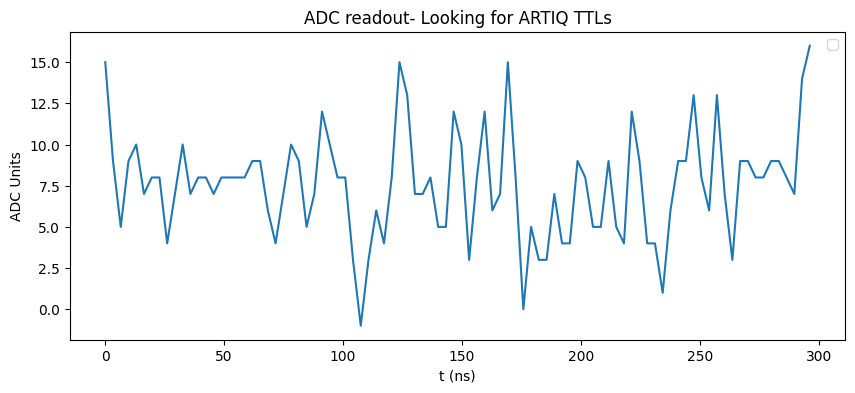

In [127]:
from qickdawg.nvpulsing.rfpulsetriggerout import RFPulseTriggerOut
soc = qd.soc
config = copy(default_config)

config.adc_channel = 0
config.adc_trig_offset_tns = 0
config.sync_delay_tns = 1000
config.readout_integration_tns = 300
config.relax_delay_tns = 200
config.readout_threshold = 1000
config.mw_channel = 0
config.mw_fMHz = 200                    # MW frequency; fMHz, freg, fGHz
config.mw_pulse_len_tns = 100           # MW pulse duration; tus, tns, treg
config.reps = 1
config.gain = 8000 # up to 32767 
config.mw_num_pulses = 3
config.inherent_trigger_to_pulses_delay_tns = 0

config.pmod_out_pin = 0
config.pmod_out_pulse_width_tns = 500
config.inherent_trigger_to_pulses_delay_tns = 209.27  
config.pmod_out_trig_delay_tns = 200 

prog = RFPulseTriggerOut(config)  # This does 2 rf pulses
# prog.acquire(soc, start_src="external", progress=False)
iq_list = prog.acquire_decimated(soc, start_src="external", progress=False)
# iq_list = prog.acquire(soc, start_src="external", progress=False)
# print(iq_list)
t_ns = 1/0.3072
time_axis = np.arange(len(iq_list)) * t_ns
plt.figure(figsize=(10,4))
plt.plot(time_axis, iq_list)
plt.title("ADC readout- Looking for ARTIQ TTLs")
plt.xlabel("t (ns)")
plt.ylabel("ADC Units")
plt.legend()
plt.show()

## CPMGXYN

In [128]:
from qickdawg.nvpulsing.CPMGXY8 import CPMGXY8AnyNFineRes

soc = qd.soc
config = copy(default_config)

config.adc_channel = 0
config.readout_integration_tns = 1000
config.pmod_out_trigger = 0
config.pmod_out_trigger_width_tns = 50   #TTL out pulse duration            
config.relax_delay_tns = 2 

config.mw_pi2_tdds = 100
config.freq_fMHz = 200                    # MW frequency; fMHz, freg, fGHz
config.mw_channel = 0
config.mw_gain = 8000 # up to 32767 
config.scaling_mode = "linear"
config.reps = 1
config.pmod_out_pin = 0
config.pmod_out_pulse_width_tns = 200
config.pmod_out_trig_delay_tns = 200
config.inherent_trigger_to_pulses_delay_tns = 200
config.pulse_seq_delay_tns = 100

config.delay_tdds_start = 500
config.delay_tdds_end = 1000
config.nsweep_points = 5
config.n_cpmg = 8

prog = CPMGXY8AnyNFineRes(config)  # This does 2 rf pulses
prog.run_rounds(soc, start_src="external", progress=False)

# prog.acquire(soc, start_src="external", progress=False)
# iq_list = prog.acquire_decimated(soc, start_src="external", load_pulses=True, progress=False)
# t_ns = 1/0.3072
# time_axis = np.arange(len(iq_list)) * t_ns
# plt.figure(figsize=(10,4))
# plt.plot(time_axis, iq_list, label="I (In-phase / Voltage)")
# plt.title("ADC Raw Trace - Looking for ARTIQ TTLs")
# plt.xlabel("t (ns)")
# plt.ylabel("ADC Units")
# plt.legend()
# plt.show()

RuntimeError: these params were set for generator 0 both in default_pulse_registers and set_pulse_registers: {'gain', 'freq'}

## CPMGXYN Sweep N

In [ ]:
from qickdawg.nvpulsing.CPMGXY8_sweepn import CPMGXY8SweepNFineRes

soc = qd.soc
config = copy(default_config)

config.adc_channel = 0
config.readout_integration_tns = 1000
config.pmod_out_trigger = 0
config.pmod_out_trigger_width_tns = 200 # TTL out pulse duration            
config.relax_delay_tns = 2 

config.mw_pi2_tdds = 100
config.n_cpmg_start = 2
config.n_cpmg_end = 16
config.nsweep_points = 4   
config.freq_fMHz = 200                    # MW frequency; fMHz, freg, fGHz
config.delay_tdds = 500
config.mw_channel = 0
config.mw_gain = 8000 # up to 32767 
config.reps = 1
config.pmod_out_pin = 0
config.pmod_out_pulse_width_tns = 50
config.pmod_out_trig_delay_tns = 200
config.inherent_trigger_to_pulses_delay_tns = 200
config.pulse_seq_delay_tns = 100

prog = CPMGXY8SweepNFineRes(config)  # This does 2 rf pulses
prog.run_rounds(soc, start_src="external", progress=False)

# prog.acquire(soc, start_src="external", progress=False)
# iq_list = prog.acquire_decimated(soc, start_src="external", load_pulses=True, progress=False)
# t_ns = 1/0.3072
# time_axis = np.arange(len(iq_list)) * t_ns
# plt.figure(figsize=(10,4))
# plt.plot(time_axis, iq_list, label="I (In-phase / Voltage)")
# plt.title("ADC Raw Trace - Looking for ARTIQ TTLs")
# plt.xlabel("t (ns)")
# plt.ylabel("ADC Units")
# plt.legend()
# plt.show()

## CPMGXY8 AND SWEEP N combined

In [ ]:
from qickdawg.nvpulsing.CPMGXY8_and_readout import CPMGXY8AnyNAndReadoutFineRes

soc = qd.soc
config = copy(default_config)

# Common parameters for both sweeps
config.mw_pi2_tdds = 100
config.freq_fMHz = 200                    # MW frequency; fMHz, freg, fGHz
config.mw_channel = 0
config.mw_gain = 8000 # up to 32767 
config.scaling_mode = "linear"
config.reps = 1
config.pmod_out_pin = 0
config.pmod_out_pulse_width_tns = 50
config.inherent_trigger_to_pulses_delay_tns = 209.27  
config.pmod_out_trig_delay_tns = 200 # 62135    # delay before the MW pulse sequence
config.pulse_seq_delay_tns = 200 #15790        # the delay needed after the MW pulse sequence

# XYN
config.delay_tdds_start = 500
config.delay_tdds_end = 1000
config.nsweep_points = 4
config.n_cpmg = 8

config.adc_channel = 0
config.adc_trig_offset_tns = 0
config.readout_integration_tns = 300 # ADC samples at 307.2 MHz, 
config.readout_threshold = 500000
config.ttlreadout_to_adc_delay_tns = 4600 + 300  #  counting duration + artiq processing time (5 us?)
config.relax_delay_tns = 200
config.f_res_fMHz = 200
prog = CPMGXY8AnyNAndReadoutFineRes(config)
# prog.run_rounds(soc, start_src="external", progress=False)

# prog.acquire(soc, rounds=0, start_src="external")
iq_list = prog.acquire_decimated(soc, start_src="external", progress=False)
# iq_list = prog.acquire(soc, start_src="external", progress=False)
# print(iq_list)
# prog.run_rounds(soc, progress=False)
t_ns = 1/0.3072
time_axis = np.arange(len(iq_list)) * t_ns
plt.figure(figsize=(10,4))
plt.plot(time_axis, iq_list)
plt.title("ADC readout- Looking for ARTIQ TTLs")
plt.xlabel("t (ns)")
plt.ylabel("ADC Units")
plt.legend()
plt.show()

## Looping QICK ADC readout until an event occurs

In [ ]:
from qickdawg.nvpulsing.CPMGXY8_ReadoutLooping import CPMGXY8AnyNLoopReadoutFineRes

soc = qd.soc
config = copy(default_config)

# Common parameters for both sweeps
config.mw_pi2_tdds = 100
config.freq_fMHz = 200                    # MW frequency; fMHz, freg, fGHz
config.mw_channel = 0
config.mw_gain = 8000 # up to 32767 
config.scaling_mode = "linear"
config.reps = 1
config.pmod_out_pin = 0
config.pmod_out_pulse_width_tns = 500
config.inherent_trigger_to_pulses_delay_tns = 209.27  
config.pmod_out_trig_delay_tns = 200 # 62135    # delay before the MW pulse sequence
config.pulse_seq_delay_tns = 200 #15790        # the delay needed after the MW pulse sequence

# XYN
config.delay_tdds_start = 500
config.delay_tdds_end = 1000
config.nsweep_points = 4
config.n_cpmg = 8

config.adc_channel = 0
config.readout_integration_tns = 200 # ADC samples at 307.2 MHz, 
# so 400 ns corresponds to about 123 samples
config.readout_threshold_value = 1000000
config.ttlreadout_to_adc_delay_tns = 4600 + 300  #  counting duration + artiq processing time (5 us?)
config.relax_delay_tns = 200
config.adc_trig_offset_tns = 0
config.f_res_fMHz = 200
prog = CPMGXY8AnyNLoopReadoutFineRes(config)
# prog.run_rounds(soc, progress=False)
prog.run_rounds(soc, start_src="external", progress=False)

## Photon measurement -> CPMGXY# + tau

In [ ]:
from qickdawg.nvpulsing.CPMGXYNtau_readout import CPMGXY8AnyNTauAndReadoutFineRes

soc = qd.soc
config = copy(default_config)

# Common parameters for both sweeps
config.mw_pi2_tdds = 100
config.freq_fMHz = 200                    # MW frequency; fMHz, freg, fGHz
config.mw_channel = 0
config.mw_gain = 8000 # up to 32767 
config.scaling_mode = "linear"
config.reps = 1
config.pmod_out_pin = 0
config.pmod_out_pulse_width_tns = 50
config.inherent_trigger_to_pulses_delay_tns = 209.27  
config.pmod_out_trig_delay_tns = 200 # 62135    # delay before the MW pulse sequence
config.pulse_seq_delay_tns = 200 #15790        # the delay needed after the MW pulse sequence

config.delay_tdds_start = 500
config.delay_tdds_end = 1000
config.nsweep_points = 4
config.n_cpmg = 8

config.adc_channel = 0
config.readout_integration_tns = 200 
config.readout_threshold_value = 10000
config.ttlreadout_to_adc_delay_tns = 3520  #  counting duration + artiq processing time (5 us?)
config.relax_delay_tns = 200
config.adc_trig_offset_tns = 0    # seems like adc readout happens 105 seconds later after pmod out
config.f_res_fMHz = 200
prog = CPMGXY8AnyNTauAndReadoutFineRes(config)

iq_list = prog.acquire(soc, start_src="external", progress=False)
print(iq_list)

## CPMGXY8AnyNMidMeas

In [ ]:
from qickdawg.nvpulsing.CPMGXY8_MidMeas import CPMGXY8AnyNMidMeas

soc = qd.soc
config = copy(default_config)

# Common parameters for both sweeps
config.mw_pi2_tdds = 100
config.freq_fMHz = 200                    # MW frequency; fMHz, freg, fGHz
config.mw_channel = 0
config.mw_gain = 8000 # up to 32767 
config.scaling_mode = "linear"
config.reps = 1
config.pmod_out_pin = 0
config.pmod_out_pulse_width_tns = 50
config.inherent_trigger_to_pulses_delay_tns = 209.27  
config.pmod_out_trig_delay_tns = 200 # 62135    # delay before the MW pulse sequence
config.pulse_seq_delay_tns = 200 #15790        # the delay needed after the MW pulse sequence

# 

# XYN
config.delay_tdds_start = 500
config.delay_tdds_end = 1000
config.nsweep_points = 4
config.n_cpmg = 8
config.delay_tdds = 500


config.adc_channel = 0
config.readout_integration_tns = 200 # ADC samples at 307.2 MHz, # so 400 ns corresponds to about 123 samples
config.readout_threshold_value = 12000


sr = 10000 # ns
cr = 4000 # ns
op = 5000 # ns
artiq_processing_time_ns = 4600
artiq_counting_duration_ns = op + sr + cr 
last_mw_pulse_to_adc_delay_ns = artiq_processing_time_ns + artiq_counting_duration_ns

config.ttlreadout_to_adc_delay_tns = last_mw_pulse_to_adc_delay_ns  #  counting duration + artiq processing time (5 us?)
config.relax_delay_tns = 200
config.adc_trig_offset_tns = 0
config.f_res_fMHz = 200
prog = CPMGXY8AnyNMidMeas(config)

iq_list = prog.acquire(soc, start_src="external", progress=False)
print(iq_list)


## Red rabi mbi

In [ ]:
from qickdawg.nvpulsing.arqick_rabi_mbi_200ps import RabiMbiFineRes

soc = qd.soc
config = copy(default_config)
read_to_green_tus = 0.190
green_to_red1_tus = 0.345
green_to_red2_tus = 0.320
read_to_red1_tus = read_to_green_tus + green_to_red1_tus
red2_to_red1_tus = green_to_red1_tus - green_to_red2_tus
green_init_duration_tus = 5
delay_after_prep_nv_tus = 12
ttl5_pulse_width_tns = 500
delay_after_ttl5_pulse_tus = 12
qick_procesing_time_after_readout_tus = 5
a1_optical_pump_tus = 5
after_red_op_to_mw_buffer_tus = 2
after_mw_to_spin_readout_buffer_tus = 0.100
ex_spin_readout_tus = 10
wait_time_tus = 0.5
charge_readout_tus = 4
delay_after_pulse_artiq_tus = 15

config.edge_counting = False
config.mw_duration_tdds_start = 500
config.mw_duration_tdds_end = 1000
config.nsweep_points = 20
config.freq_fMHz = 200                
config.mw_channel = 0
config.mw_nqz = 1
config.mw_gain = 8000 
config.reps = 1
config.pmod_out_pin = 0
config.pmod_out_pulse_width_tns = 300
# config.pmod_out_trig_delay_tus = round(delay_after_ttl5_pulse_tus + read_to_red1_tus 
#                                        + a1_optical_pump_tus + after_red_op_to_mw_buffer_tus, 5) # before delay |the delay before qick pulses | to account for inherent delay for mw pulse to come out

prep_nv_total_duration_tus = (read_to_red1_tus + green_init_duration_tus + 
                              charge_readout_tus + delay_after_prep_nv_tus)
# config.pmod_out_trig_delay_tus = round(delay_after_ttl5_pulse_tus + hundredthirty_ns_tus + a1_optical_pump_tus 
#                                        + after_red_op_to_mw_buffer_tus, 5)  # before delay |the delay before qick pulses | to account for inherent delay for mw pulse to come out
config.pmod_out_trig_delay_tus = round(delay_after_ttl5_pulse_tus + a1_optical_pump_tus 
                                       + after_red_op_to_mw_buffer_tus, 5)  # before delay |the delay before qick pulses | to account for inherent delay for mw pulse to come out

config.inherent_trigger_to_pulses_delay_tns = 209.27
config.pulse_seq_delay_tus = round(after_mw_to_spin_readout_buffer_tus + ex_spin_readout_tus 
                                   + wait_time_tus + charge_readout_tus + delay_after_pulse_artiq_tus 
                                   + prep_nv_total_duration_tus, 5)         # after delay | the delay after qick pulses
config.adc_channel = 0
config.adc_trig_offset_tns = 0
config.readout_threshold = 5000
config.readout_integration_tns = 1000
config.extra_delay_tus = 1
config.qick_processing_time_after_readout_tus = qick_procesing_time_after_readout_tus
config.delay_before_readout_repeats_tus = round((green_init_duration_tus + charge_readout_tus + 
                                                 delay_after_prep_nv_tus - green_to_red1_tus - config.extra_delay_tus), 5)
# config.delay_before_readout_repeats_tus = round((prep_nv_total_duration_tus - config.pmod_out_pulse_width_tns), 5)
                                                                        # - 0.345us - 1us
# config.delay_after_first_pmod_out_tus = round((red2_to_red1_tus + fourten_ns_tus + green_init_duration_tus 
#                                                + charge_readout_tus + delay_after_prep_nv_tus), 5)
reset_register_time_tus = 0.123
config.delay_after_first_pmod_out_tus = round((prep_nv_total_duration_tus - reset_register_time_tus), 5)
print(green_init_duration_tus + charge_readout_tus + delay_after_prep_nv_tus - green_to_red1_tus - config.extra_delay_tus)
print("RABI MBI")
print("prep_nv_total_duration_tus:", prep_nv_total_duration_tus)
print("(before delay) pmod_out_trig_delay_tus:", config.pmod_out_trig_delay_tus)
print("delay_after_first_pmod_out_tus:", config.delay_after_first_pmod_out_tus)
print("delay_before_readout_repeats_tus:", config.delay_before_readout_repeats_tus)
print("(after delay) pulse_seq_delay_tus:", config.pulse_seq_delay_tus)
prog = RabiMbiFineRes(config)
prog.run_rounds(soc, rounds=1, start_src="external")
# prog = RabiMbiFineRes(config)
# prog.acquire(soc, start_src="external")
# data = prog.acquire_decimated(soc, start_src="external", progress=False)
# print(data)
# t_ns = 1/0.3072
# time_axis = np.arange(len(data)) * t_ns
# plt.figure(figsize=(10,4))
# plt.plot(time_axis, data)
# plt.title("ADC readout- Looking for TTL")
# plt.xlabel("t (ns)")
# plt.ylabel("ADC Units")
# plt.legend()
# plt.show()

19.65565104166667
RABI MBI
prep_nv_total_duration_tus: 21.535
(before delay) pmod_out_trig_delay_tus: 19.000651041666668
delay_after_first_pmod_out_tus: 21.412760416666668
delay_before_readout_repeats_tus: 19.654947916666668
(after delay) pulse_seq_delay_tus: 51.136067708333336


100%|██████████| 20/20 [00:04<00:00,  4.96it/s]


## Red CPMGXY8 mbi

In [141]:
from qickdawg.nvpulsing.arqick_cpmgxy8_variable_n_mbi_200ps import CPMGXY8VarNFineRes

soc = qd.soc
config = copy(default_config)
read_to_green_tus = 0.190
green_to_red1_tus = 0.345
green_to_red2_tus = 0.320
read_to_red1_tus = read_to_green_tus + green_to_red1_tus
red2_to_red1_tus = green_to_red1_tus - green_to_red2_tus
green_init_duration_tus = 5
delay_after_prep_nv_tus = 12
ttl5_pulse_width_tns = 500
delay_after_ttl5_pulse_tus = 12
qick_procesing_time_after_readout_tus = 5
a1_optical_pump_tus = 50
after_red_op_to_mw_buffer_tus = 2
after_mw_to_spin_readout_buffer_tus = 0.100
ex_spin_readout_tus = 25
wait_time_tus = 0.5
charge_readout_tus = 20
delay_after_pulse_artiq_tus = 15
prep_nv_total_duration_tus = (read_to_red1_tus + green_init_duration_tus + 
                              charge_readout_tus + delay_after_prep_nv_tus)

config.edge_counting = False
config.delay_tdds_start = 500 # 500, 625, 750, 875, 1000.
config.delay_tdds_end = 1000
config.nsweep_points = 10
config.n_cpmg = 8
config.mw_pi2_tdds = 95
config.freq_fMHz = 200                
config.mw_channel = 0
config.mw_nqz = 1
config.mw_gain = 8000
config.scaling_mode = "linear"
config.reps = 1
config.pmod_out_pin = 0
config.pmod_out_pulse_width_tns = 300
# 12 + 5 + 2 = 19
config.pmod_out_trig_delay_tus = round(delay_after_ttl5_pulse_tus + a1_optical_pump_tus 
                                       + after_red_op_to_mw_buffer_tus, 5)  # before delay |the delay before qick pulses | to account for inherent delay for mw pulse to come out

config.inherent_trigger_to_pulses_delay_tns = 209.27
# 100 ns + 10us + 0.5us + 4us + 15us + 21.535us = 51.635 us
delay_to_align_ttl5_to_readout_window_tus = 0.125

config.pulse_seq_delay_tus = round(after_mw_to_spin_readout_buffer_tus + ex_spin_readout_tus 
                                   + wait_time_tus + charge_readout_tus + delay_after_pulse_artiq_tus 
                                   + prep_nv_total_duration_tus + delay_to_align_ttl5_to_readout_window_tus, 5)         # after delay | the delay after qick pulses
config.adc_channel = 0
config.adc_trig_offset_tns = 0
config.readout_threshold = 5000
config.readout_integration_tns = 1000
config.extra_delay_tus = 1
config.qick_processing_time_after_readout_tus = qick_procesing_time_after_readout_tus
config.delay_before_readout_repeats_tus = round((green_init_duration_tus + charge_readout_tus 
                                                 + delay_after_prep_nv_tus - green_to_red1_tus 
                                                 - config.extra_delay_tus), 5)

# reset_register_time_tus = 0.123
config.delay_after_first_pmod_out_tus = round((prep_nv_total_duration_tus), 5)
print("CPMG MBI")
print(green_init_duration_tus + charge_readout_tus + delay_after_prep_nv_tus - green_to_red1_tus - config.extra_delay_tus)
print("prep_nv_total_duration_tus:", prep_nv_total_duration_tus)
print("(before delay) pmod_out_trig_delay_tus:", config.pmod_out_trig_delay_tus)
print("delay_after_first_pmod_out_tus:", config.delay_after_first_pmod_out_tus)
print("delay_before_readout_repeats_tus:", config.delay_before_readout_repeats_tus)
print("(after delay) pulse_seq_delay_tus:", config.pulse_seq_delay_tus)
prog = CPMGXY8VarNFineRes(config)  # prog = RabiMbiFineRes(config)
prog.run_rounds(soc, rounds=1, start_src="external")

CPMG MBI
35.655651041666665
prep_nv_total_duration_tus: 37.535
(before delay) pmod_out_trig_delay_tus: 64.00065104166667
delay_after_first_pmod_out_tus: 37.53580729166667
delay_before_readout_repeats_tus: 35.654296875
(after delay) pulse_seq_delay_tus: 98.25846354166667


100%|██████████| 10/10 [00:03<00:00,  3.02it/s]
